In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
#Translated Rate Eqns from Matlab 
def laser_rate_equations(t, y, I):
    
    S, N = y
    # laser parameters
    tp = 3e-12 # photon lifetime, s
    ts = 2e-9 # carrier lifetime, s
    G0 = 1e4 # Modal gain, s-1
    Ntr = 4e6 # Transparency carrier number
    eta = 0.9 # Quantum efficiency
    Rsp = 100e9 # Spontaneous emission rate
    q = 1.6e-19
    
    G = G0 * (N - Ntr)
    
    dy = np.zeros(2)
    dy[0] = (G - 1/tp) * S + Rsp        # dS/dt, photon number
    dy[1] = eta * I / q - N/ts - G * S  # dN/dt, carrier number
    
    return dy




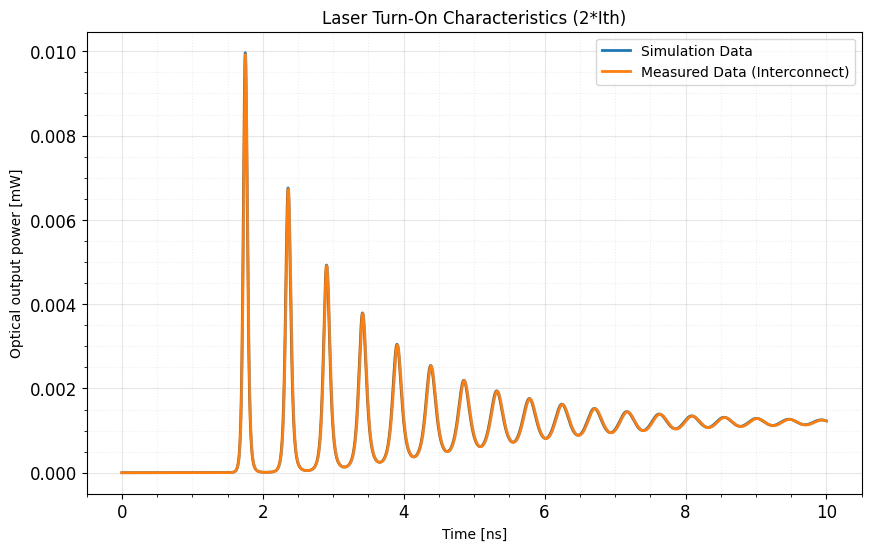

In [23]:
y0 = [0, 0]  # [S, N] = [photon number, carrier number]

I_bias = I_th * 2
delay = 1E-12
t_span = (0 + delay, 1e-8 + delay)
t_eval = np.linspace(0 + delay, 1e-8 + delay, 16000)

def current_function(t, I_bias=I_bias):
    return I_bias  

def rate_equations_with_current(t, y):
    I = current_function(t)
    return laser_rate_equations(t, y, I)

sol = solve_ivp(
    rate_equations_with_current,
    t_span,
    y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-6, 
    atol=1e-6  
)

t = sol.t
S = sol.y[0]
N = sol.y[1]
I_th = 0.003323
optical_power = S * 4.27e-8 / 2

with h5py.File('2Ithturnon.mat', 'r') as mat_data:
    mat_time = np.linspace(0, 1e-8, 16000)
    mat_power = np.array(mat_data['pwr']).flatten()

plt.figure(figsize=(10, 6))
plt.plot(mat_time * 1e9, optical_power, linewidth=2, label='Simulation Data')
plt.plot(mat_time * 1e9, mat_power, linestyle='-', linewidth=2, label='Measured Data (Interconnect)')

plt.xlabel('Time [ns]')
plt.ylabel('Optical output power [mW]')
plt.title(f'Laser Turn-On Characteristics ({2}*Ith)')
plt.grid(True, which='both', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)
plt.minorticks_on()
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

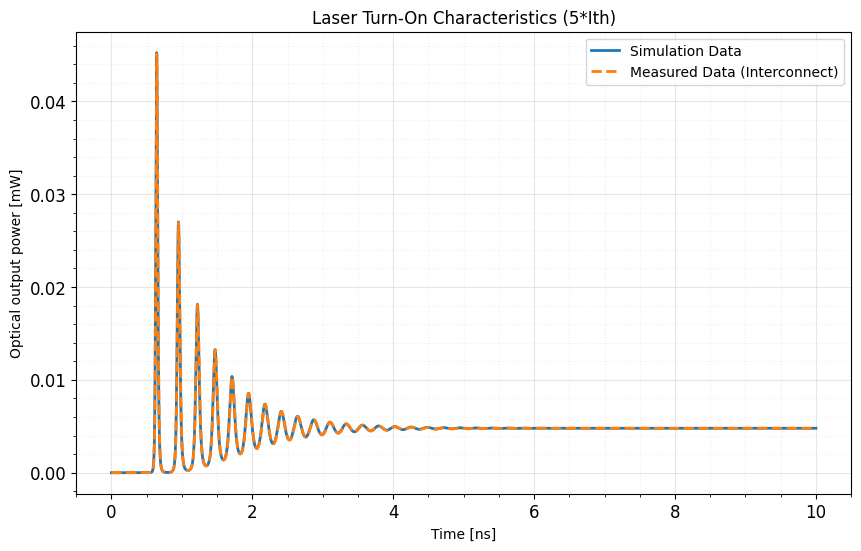

In [19]:
y0 = [0, 0]  # [S, N] = [photon number, carrier number]

I_bias = I_th * 5
delay = 1E-12
t_span = (0 + delay, 1e-8 + delay)
t_eval = np.linspace(0 + delay, 1e-8 + delay, 16000)

def current_function(t, I_bias=I_bias):
    return I_bias  

def rate_equations_with_current(t, y):
    I = current_function(t)
    return laser_rate_equations(t, y, I)

sol = solve_ivp(
    rate_equations_with_current,
    t_span,
    y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-6, 
    atol=1e-6  
)

t = sol.t
S = sol.y[0]
N = sol.y[1]
I_th = 0.003323
optical_power = S * 4.27e-8 / 2

with h5py.File('5Ithturnon.mat', 'r') as mat_data:
    mat_time = np.linspace(0, 1e-8, 16000)
    mat_power = np.array(mat_data['pwr']).flatten()

plt.figure(figsize=(10, 6))
plt.plot(mat_time * 1e9, optical_power, linewidth=2, label='Simulation Data')
plt.plot(mat_time * 1e9, mat_power, linestyle='--', linewidth=2, label='Measured Data (Interconnect)')

plt.xlabel('Time [ns]')
plt.ylabel('Optical output power [mW]')
plt.title(f'Laser Turn-On Characteristics ({5}*Ith)')
plt.grid(True, which='both', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)
plt.minorticks_on()
plt.tick_params(labelsize=12)
plt.legend()
plt.show()

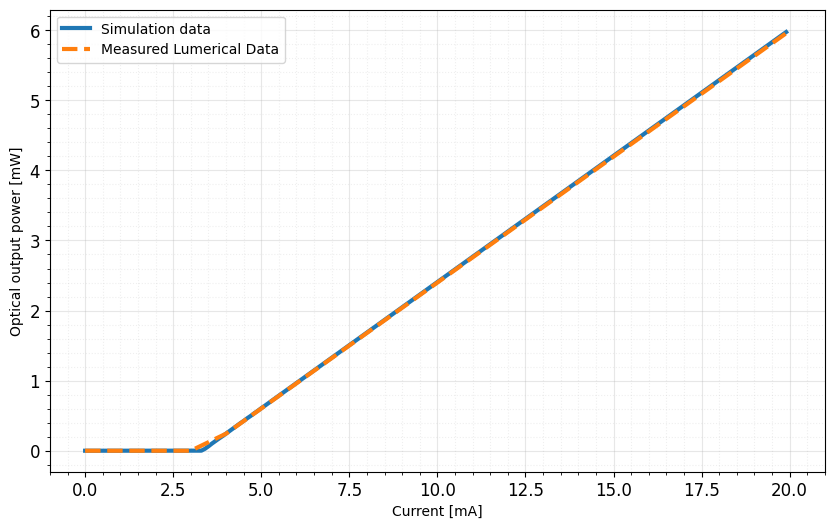

In [21]:
y0 = [0, 0]

I_sweep = np.arange(0, 20e-3, 0.1e-3)

S_sweep = np.zeros(len(I_sweep))
N_sweep = np.zeros(len(I_sweep))

t_span = (0, 10e-9) 

for i, I in enumerate(I_sweep):
    if i > 0:
        y0 = [S_sweep[i-1], N_sweep[i-1]]
    
    sol = solve_ivp(
        laser_rate_equations,
        t_span,
        y0,
        args=(I,),
        method='RK45',
        rtol=1e-6,
        atol=1e-6
    )
    S_sweep[i] = sol.y[0, -1]
    N_sweep[i] = sol.y[1, -1]

plt.figure(figsize=(10, 6))
plt.plot(I_sweep * 1e3, S_sweep * 4.27e-8 * 1e3 / 2, linewidth=3, label='Simulation data')

with h5py.File("LI.mat", 'r') as mat_data:
    current_ref = mat_data['r']['current'][0, 0]
    current_values = np.array(mat_data[current_ref]).flatten()
    pwr_ref = mat_data['r']['power__W_'][0, 0]
    power_values = np.array(mat_data[pwr_ref]).flatten()
    
plt.plot(current_values * 1e3, power_values * 1e3, linestyle='--', linewidth=3, label='Measured Lumerical Data')

plt.xlabel('Current [mA]')
plt.ylabel('Optical output power [mW]')
plt.grid(True, which='both', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)
plt.minorticks_on()
plt.tick_params(labelsize=12)
plt.legend()
plt.show()


In [6]:
from jitcdde import jitcdde, y, t
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
tau = 5e-12
tau_in = 1e-12
R2 = 0.99
R3 = 0.99
alpha = 4
G0 = 1e4
Nth = 4e6
eta = 0.9
Rsp = 1e9
q = 1.6e-19
tp = 3e-12
ts = 2e-9
omega0 = 2 * np.pi * 193.1e12
I = 1e-3

kappa = (1 - R2) * np.sqrt(R3) / (tau_in * np.sqrt(R2))

# === Define DDE right-hand side as symbolic expressions ===
S = y(0)
phi = y(1)
N = y(2)

Slag = y(0, t - tau)
philag = y(1, t - tau)

G = G0 * (N - Nth)

dSdt = (G - 1 / tp) * S + Rsp + 2 * kappa * (S * Slag)**0.5 * np.cos(omega0 * tau + phi - philag)
dphidt = 0.5 * alpha * G - kappa * (Slag / S)**0.5 * np.sin(omega0 * tau + phi - philag)
dNdt = eta * I / q - N / ts - G * S

f_sym = [dSdt, dphidt, dNdt]

# === Solver Setup ===
dde = jitcdde(f_sym)
initial_history = [1e6, 0.0, 0.1e6]
dde.constant_past(initial_history)
dde.compile()

# === Time Parameters ===
time_period = 20e-9
max_step = 1e-4 * time_period
times = np.arange(0, time_period, max_step)

# === Run Simulation ===
sol = np.array([dde.integrate(ti) for ti in times])

# === Plot ===
plt.figure()
plt.plot(times * 1e9, sol[:, 0])
plt.xlabel("Time (ns)")
plt.ylabel("Photon Number S")
plt.title("Photon Number with Delayed Feedback")
plt.grid()
plt.show()

TypeError: loop of ufunc does not support argument 0 of type Add which has no callable cos method